<a href="https://colab.research.google.com/github/Jiaze-G/resume-hiring-prediction-ml/blob/main/Modeling_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modeling and Evaluation
## Overview:
This file aims to build different models and evaluate them.
## Purpose:

## Setup

In [86]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    auc
)

from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

In [57]:

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
def metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return acc, prec, rec, f1

In [59]:

DATA_DIR = "/content/drive/MyDrive/EE344/final project/processed"

# Load the data
X_train = pd.read_parquet(f"{DATA_DIR}/X_train.parquet")
X_test  = pd.read_parquet(f"{DATA_DIR}/X_test.parquet")

y_train = pd.read_parquet(f"{DATA_DIR}/y_train.parquet")["target"]
y_test  = pd.read_parquet(f"{DATA_DIR}/y_test.parquet")["target"]

y_train = y_train.map({'Hire': 1, 'Reject': 0})
y_test = y_test.map({'Hire': 1, 'Reject': 0})
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("\nTraining label distribution:")
print(y_train.value_counts())

Training feature shape: (800, 114)
Testing feature shape: (200, 114)

Training label distribution:
target
1    650
0    150
Name: count, dtype: int64


**Preprocessing and Scaling**

In [60]:
scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

**Applying Models**

In [61]:
model_list = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Perceptron": Perceptron(random_state=42),
    "Linear SVM": LinearSVC(max_iter=2000, random_state=42),
    "Multinomial NB": MultinomialNB(),
    "KNN (cosine)": KNeighborsClassifier(n_neighbors=5, metric='cosine'),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

if XGBClassifier:
    model_list["XGBoost"] = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

**Training and Evaluation**

In [62]:
results = []
trained_models = {}
for name, model in model_list.items():
    # Train on scaled data and numeric labels
    model.fit(X_train_scaled, y_train)

    trained_models[name] = model

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    # Calculate metrics (now pos_label=1 will work correctly)
    train_metrics = metrics(y_train, y_train_pred)
    test_metrics = metrics(y_test, y_test_pred)

    # Store
    results.append([name] + list(train_metrics) + list(test_metrics))

cols = [
    "Model",
    "Train Acc", "Train Prec", "Train Rec", "Train F1",
    "Test Acc", "Test Prec", "Test Rec", "Test F1",
]

out = pd.DataFrame(results, columns=cols).sort_values("Test F1", ascending=False).reset_index(drop=True)

pd.set_option("display.max_colwidth", 80)
print("\n=== Results (sorted by Test F1) ===")
print(out.to_string(index=False, formatters={
    "Train Acc": "{:.4f}".format,
    "Train Prec": "{:.4f}".format,
    "Train Rec": "{:.4f}".format,
    "Train F1": "{:.4f}".format,
    "Test Acc": "{:.4f}".format,
    "Test Prec": "{:.4f}".format,
    "Test Rec": "{:.4f}".format,
    "Test F1": "{:.4f}".format,
}))


=== Results (sorted by Test F1) ===
              Model Train Acc Train Prec Train Rec Train F1 Test Acc Test Prec Test Rec Test F1
            XGBoost    1.0000     1.0000    1.0000   1.0000   0.9600    0.9753   0.9753  0.9753
         Perceptron    0.9812     0.9953    0.9815   0.9884   0.9550    0.9873   0.9568  0.9718
Logistic Regression    0.9838     0.9833    0.9969   0.9901   0.9450    0.9576   0.9753  0.9664
      Decision Tree    1.0000     1.0000    1.0000   1.0000   0.9450    0.9748   0.9568  0.9657
      Random Forest    1.0000     1.0000    1.0000   1.0000   0.9400    0.9464   0.9815  0.9636
         Linear SVM    0.9938     0.9954    0.9969   0.9962   0.9400    0.9630   0.9630  0.9630
     Multinomial NB    0.8213     0.8213    0.9969   0.9006   0.8050    0.8090   0.9938  0.8920
       KNN (cosine)    0.8413     0.8436    0.9877   0.9100   0.8000    0.8144   0.9753  0.8876


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:23:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Train Acc,Train Prec,Train Rec,Train F1,Test Acc,Test Prec,Test Rec,Test F1
0,XGBoost,1.0000,1.0000,1.0000,1.0000,0.960,0.9753,0.9753,0.9753
1,Perceptron,0.9812,0.9953,0.9815,0.9884,0.955,0.9873,0.9568,0.9718
2,Logistic Regression,0.9838,0.9833,0.9969,0.9901,0.945,0.9576,0.9753,0.9664
3,Decision Tree,1.0000,1.0000,1.0000,1.0000,0.945,0.9748,0.9568,0.9657
4,Random Forest,1.0000,1.0000,1.0000,1.0000,0.940,0.9464,0.9815,0.9636
5,Linear SVM,0.9938,0.9954,0.9969,0.9962,0.940,0.9630,0.9630,0.9630
6,Multinomial NB,0.8212,0.8213,0.9969,0.9006,0.805,0.8090,0.9938,0.8920
7,KNN (cosine),0.8412,0.8436,0.9877,0.9100,0.800,0.8144,0.9753,0.8876


/tmp/ipykernel_514/1641844635.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=out, x="Test F1", y="Model", palette="viridis")


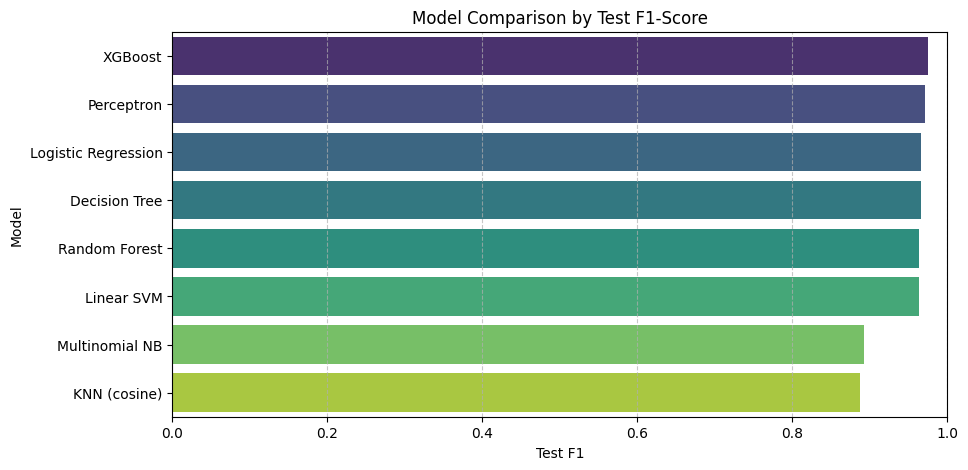

In [63]:
# Assuming 'out' is the DataFrame generated by your loop
# Sort by Test F1 (if not already sorted)
out = out.sort_values("Test F1", ascending=False).reset_index(drop=True)

# Display the rounded table
display(out.round(4))

# Plotting the Model Comparison
plt.figure(figsize=(10, 5))
# Use the column names from your 'out' DataFrame
sns.barplot(data=out, x="Test F1", y="Model", palette="viridis")
plt.title("Model Comparison by Test F1-Score")
plt.xlim(0, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

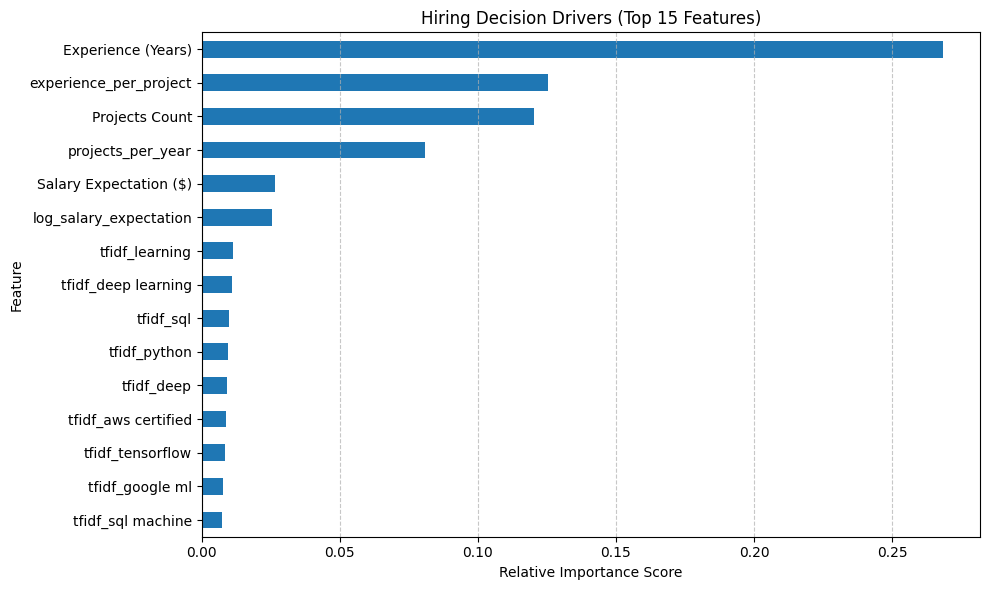

In [64]:
rf_model = trained_models["Random Forest"]#why random forest

importances = rf_model.feature_importances_
feat_names = X_train_scaled.columns

feature_imp_series = pd.Series(importances, index=feat_names)

top_15_features = feature_imp_series.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
top_15_features.sort_values().plot(kind="barh")

plt.title("Hiring Decision Drivers (Top 15 Features)")
plt.xlabel("Relative Importance Score")
plt.ylabel("Feature")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

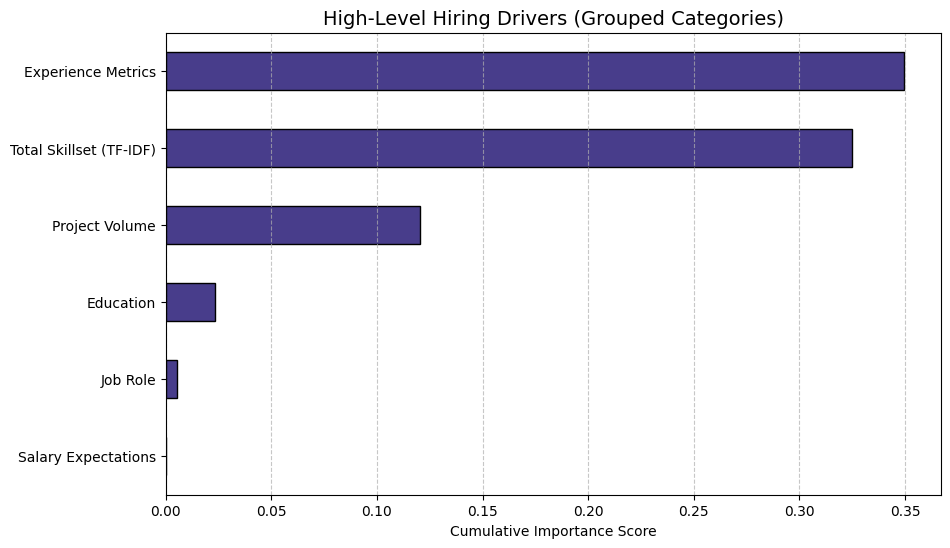

In [65]:
# 1. Get the trained Random Forest
rf_model = trained_models["Random Forest"]
importances = rf_model.feature_importances_
feat_names = X_train_scaled.columns

# 2. Define our "Buckets"
# We categorize features based on their column name prefixes
buckets = {
    'Total Skillset (TF-IDF)': [f for f in feat_names if f.startswith('tfidf_')],
    'Experience Metrics': ['Experience (Years)', 'projects_per_year', 'exp_per_project'],
    'Project Volume': ['Projects Count'],
    'Salary Expectations': ['log_salary'],
    'Job Role': [f for f in feat_names if 'Job Role' in f],
    'Education': [f for f in feat_names if 'Edu Code' in f or 'Education' in f]
}

# 3. Sum importance for each bucket
bucket_importance = {}
for category, column_list in buckets.items():
    # Find indices of columns belonging to this bucket
    indices = [feat_names.get_loc(c) for c in column_list if c in feat_names]
    bucket_importance[category] = importances[indices].sum()

# Convert to Series and sort
bucket_series = pd.Series(bucket_importance).sort_values(ascending=True)

# 4. Plot the "Total" Chart
plt.figure(figsize=(10, 6))
bucket_series.plot(kind='barh', color='darkslateblue', edgecolor='black')
plt.title("High-Level Hiring Drivers (Grouped Categories)", fontsize=14)
plt.xlabel("Cumulative Importance Score")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

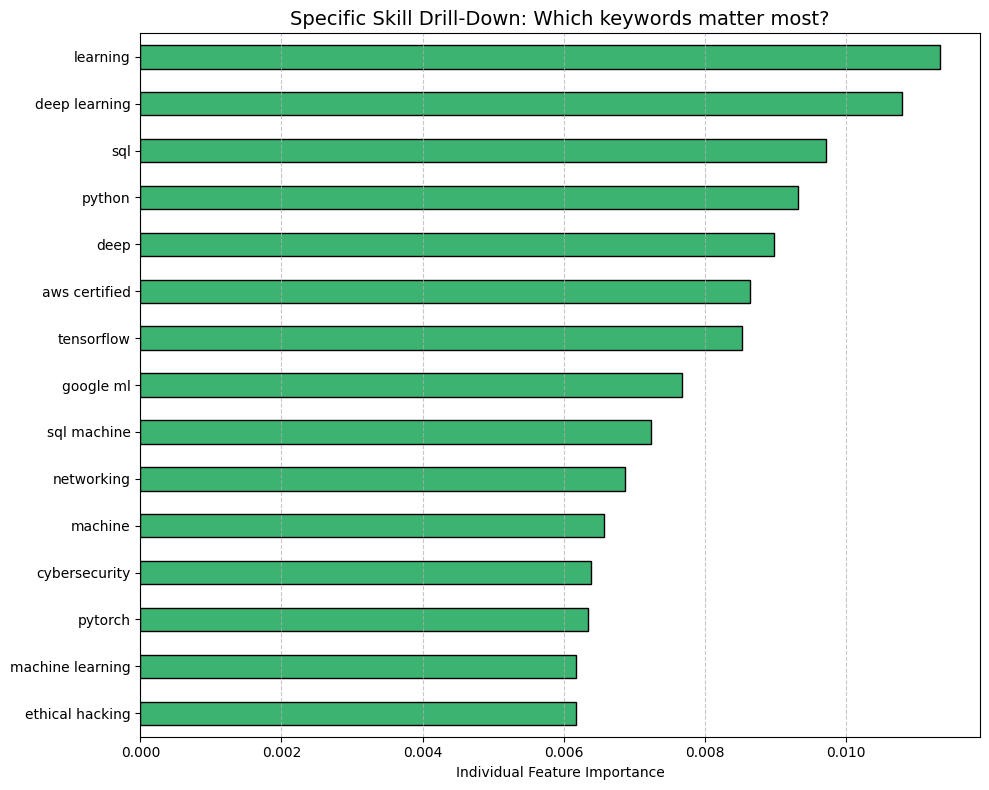

In [66]:
# 1. Filter for only TF-IDF features
skill_features = [f for f in feat_names if f.startswith('tfidf_')]
skill_importances = pd.Series(importances, index=feat_names)[skill_features]

# 2. Clean up the names (remove 'tfidf_' prefix for the chart)
skill_importances.index = [name.replace('tfidf_', '') for name in skill_importances.index]

# 3. Get Top 15 specific skills
top_skills = skill_importances.sort_values(ascending=True).tail(15)

# 4. Plot the "Drill-Down" Chart
plt.figure(figsize=(10, 8))
top_skills.plot(kind='barh', color='mediumseagreen', edgecolor='black')
plt.title("Specific Skill Drill-Down: Which keywords matter most?", fontsize=14)
plt.xlabel("Individual Feature Importance")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [67]:
print("Model features:", len(importances))
print("Dataframe features:", len(X_train.columns))

Model features: 114
Dataframe features: 114


Confusion Matrix for the best model

<Figure size 600x500 with 0 Axes>

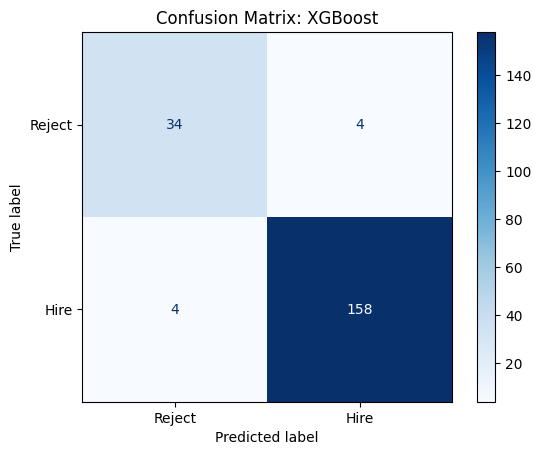

In [68]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# get best model name from your results table
best_model_name = out.iloc[0]["Model"]

best_model = trained_models[best_model_name]

# predictions
y_pred = best_model.predict(X_test_scaled)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Reject","Hire"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.grid(False)
plt.show()

Precision-Recall Curve

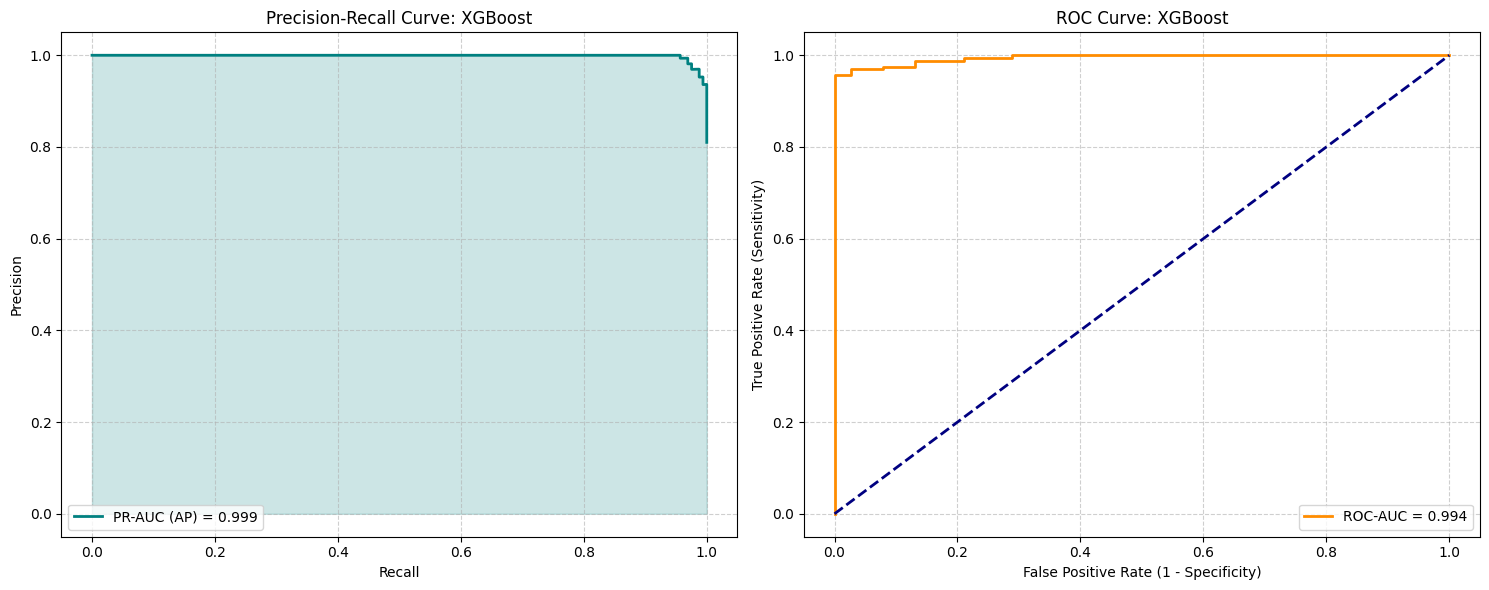

Summary for XGBoost:
Area Under Precision-Recall Curve (PR-AUC): 0.9987
Area Under ROC Curve (ROC-AUC): 0.9945


In [73]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score

# 1. Get probability scores or decision function values
if hasattr(best_model, "predict_proba"):
    y_scores = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    y_scores = best_model.decision_function(X_test_scaled)

# 2. Calculate Precision-Recall Metrics (PR-AUC)
precision, recall, _ = precision_recall_curve(y_test, y_scores)
pr_auc = average_precision_score(y_test, y_scores)

# 3. Calculate ROC Metrics (ROC-AUC)
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

# 4. Plotting both curves side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot Precision-Recall Curve
ax1.plot(recall, precision, color='teal', lw=2, label=f'PR-AUC (AP) = {pr_auc:.3f}')
ax1.fill_between(recall, precision, alpha=0.2, color='teal')
ax1.set_xlabel("Recall")
ax1.set_ylabel("Precision")
ax1.set_title(f"Precision-Recall Curve: {best_model_name}")
ax1.legend(loc="lower left")
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot ROC Curve
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-AUC = {roc_auc:.3f}')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Baseline
ax2.set_xlabel("False Positive Rate (1 - Specificity)")
ax2.set_ylabel("True Positive Rate (Sensitivity)")
ax2.set_title(f"ROC Curve: {best_model_name}")
ax2.legend(loc="lower right")
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Summary for {best_model_name}:")
print(f"Area Under Precision-Recall Curve (PR-AUC): {pr_auc:.4f}")
print(f"Area Under ROC Curve (ROC-AUC): {roc_auc:.4f}")

Deal with imbalanced dataset

we make the train set to 650/650
keep the test set

apply cv



In [76]:
from imblearn.over_sampling import SMOTE

# Scaling (Keep as DataFrame to preserve column names for feature importance)
scaler = MinMaxScaler()
X_train_scaled_array = scaler.fit_transform(X_train)
X_test_scaled_array = scaler.transform(X_test)

# Convert back to DataFrame to keep feature names
X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=X_test.columns)

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Original Training Distribution: {y_train.value_counts().to_dict()}")
print(f"Resampled Training Distribution: {pd.Series(y_train_resampled).value_counts().to_dict()}")

Original Training Distribution: {1: 650, 0: 150}
Resampled Training Distribution: {1: 650, 0: 650}


Starting Cross-Validation (SMOTE applied inside folds)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:18:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:18:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:18:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:18:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


=== Final Results (Sorted by Test F1) ===


,Model,CV_F1,CV_PR_AUC,Test Acc,Test Prec,Test Rec,Test F1
0,XGBoost,0.9755,0.9983,0.960,0.9812,0.9691,0.9752
1,Linear SVM,0.9690,0.9965,0.960,0.9873,0.9630,0.9750
2,Random Forest,0.9679,0.9957,0.955,0.9693,0.9753,0.9723
3,Decision Tree,0.9525,0.9440,0.955,0.9935,0.9506,0.9716
4,Logistic Regression,0.9603,0.9972,0.950,0.9935,0.9444,0.9684
5,Perceptron,0.9753,0.9972,0.945,1.0000,0.9321,0.9649
6,Multinomial NB,0.8124,0.9102,0.780,0.8933,0.8272,0.8590
7,KNN (cosine),0.7471,0.8693,0.655,0.8661,0.6790,0.7612


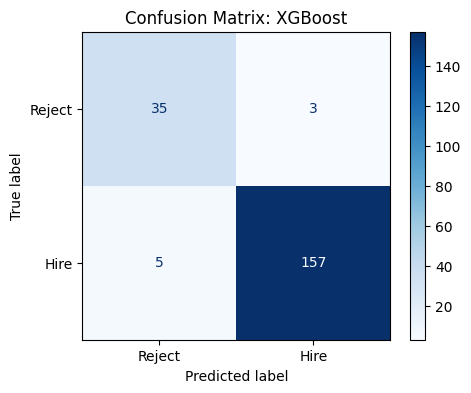

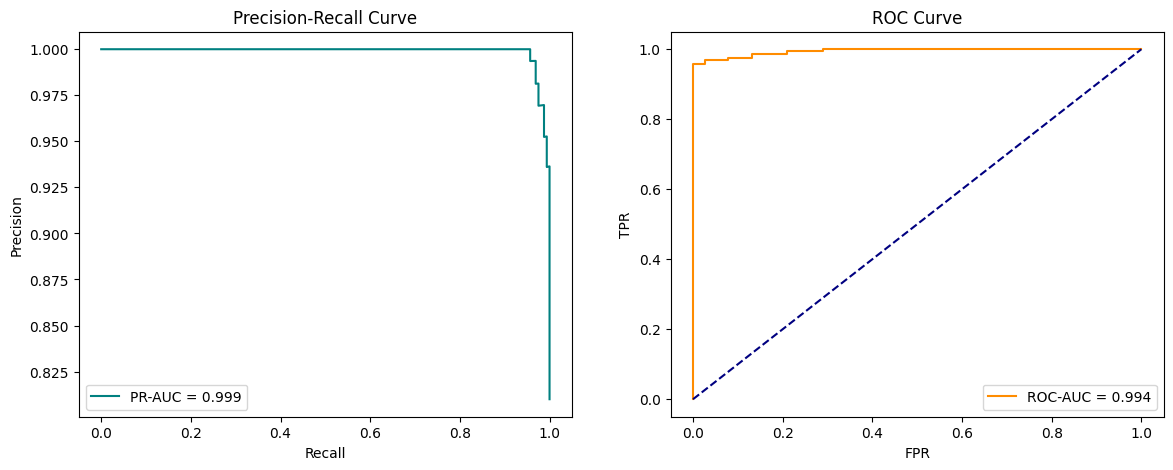

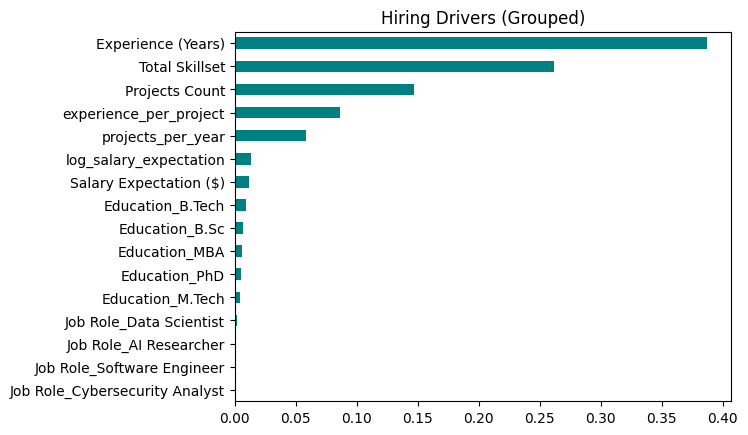

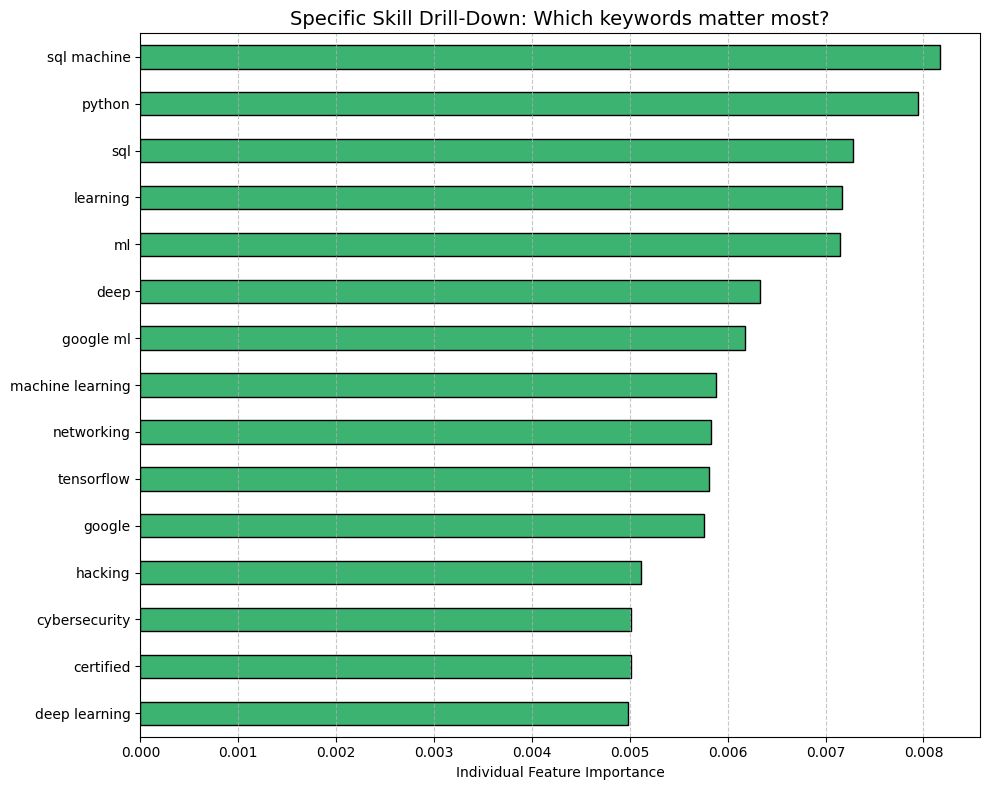

In [88]:
results = []
trained_pipelines = {}

print("Starting Cross-Validation (SMOTE applied inside folds)...")

for name, model in model_list.items():
    # Create an Imbalance-Aware Pipeline
    # scaler -> smote -> model
    # Note: SMOTE is ONLY applied to the training portion of the CV fold
    pipeline = ImbPipeline([
        ('scaler', MinMaxScaler()),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])

    # Perform 5-Fold Cross Validation on the Training Set
    # We score using F1 and PR-AUC (Average Precision)
    cv_scores = ['f1', 'average_precision']
    cv_res = cross_validate(pipeline, X_train, y_train, cv=5, scoring=cv_scores)

    mean_cv_f1 = cv_res['test_f1'].mean()
    mean_cv_ap = cv_res['test_average_precision'].mean()

    # Now train the final version of this pipeline on the FULL training set
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline

    # Evaluate on the Final Test Set
    y_test_pred = pipeline.predict(X_test)
    test_acc, test_prec, test_rec, test_f1 = metrics(y_test, y_test_pred)

    results.append([name, mean_cv_f1, mean_cv_ap, test_acc, test_prec, test_rec, test_f1])

# --- 3. TABULATE RESULTS ---

cols = ["Model", "CV_F1", "CV_PR_AUC", "Test Acc", "Test Prec", "Test Rec", "Test F1"]
out = pd.DataFrame(results, columns=cols).sort_values("Test F1", ascending=False).reset_index(drop=True)

print("\n=== Final Results (Sorted by Test F1) ===")
display(out.round(4))

# --- 4. BEST MODEL DEEP DIVE ---

best_model_name = out.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]

# Get scores for curves
if hasattr(best_pipeline.named_steps['classifier'], "predict_proba"):
    y_scores = best_pipeline.predict_proba(X_test)[:, 1]
else:
    y_scores = best_pipeline.decision_function(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, best_pipeline.predict(X_test))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Reject", "Hire"]).plot(cmap="Blues", ax=ax)
ax.set_title(f"Confusion Matrix: {best_model_name}")
plt.grid(False)
plt.show()

# Precision-Recall & ROC Curves
precision, recall, _ = precision_recall_curve(y_test, y_scores)
fpr, tpr, _ = roc_curve(y_test, y_scores)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(recall, precision, color='teal', label=f'PR-AUC = {average_precision_score(y_test, y_scores):.3f}')
ax1.set_title("Precision-Recall Curve")
ax1.set_xlabel("Recall")
ax1.set_ylabel("Precision")
ax1.legend()

ax2.plot(fpr, tpr, color='darkorange', label=f'ROC-AUC = {roc_auc_score(y_test, y_scores):.3f}')
ax2.plot([0, 1], [0, 1], linestyle='--', color='navy')
ax2.set_title("ROC Curve")
ax2.set_xlabel("FPR")
ax2.set_ylabel("TPR")
ax2.legend()
plt.show()

# --- 5. GROUPED FEATURE IMPORTANCE (Random Forest) ---

rf_model = trained_pipelines["Random Forest"].named_steps['classifier']
importances = rf_model.feature_importances_
feat_names = X_train.columns

# Sum TF-IDF scores for a "Total Skillset" view
skill_cols = [f for f in feat_names if f.startswith('tfidf_')]
other_cols = [f for f in feat_names if not f.startswith('tfidf_')]

grouped_imp = { "Total Skillset": importances[[feat_names.get_loc(c) for c in skill_cols]].sum() }
for col in other_cols:
    grouped_imp[col] = importances[feat_names.get_loc(col)]

pd.Series(grouped_imp).sort_values().plot(kind='barh', color='teal', title="Hiring Drivers (Grouped)")
plt.show()


# 1. Filter for only TF-IDF features
skill_features = [f for f in feat_names if f.startswith('tfidf_')]
skill_importances = pd.Series(importances, index=feat_names)[skill_features]

# 2. Clean up the names (remove 'tfidf_' prefix for the chart)
skill_importances.index = [name.replace('tfidf_', '') for name in skill_importances.index]

# 3. Get Top 15 specific skills
top_skills = skill_importances.sort_values(ascending=True).tail(15)

# 4. Plot the "Drill-Down" Chart
plt.figure(figsize=(10, 8))
top_skills.plot(kind='barh', color='mediumseagreen', edgecolor='black')
plt.title("Specific Skill Drill-Down: Which keywords matter most?", fontsize=14)
plt.xlabel("Individual Feature Importance")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()